In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
bids_folder_orig = f'/mnt_03/ds-{dataset}' 
plot_folder = op.join(bids_folder, 'plots_and_ims/gradient_stuff')

source_folder = op.join(bids_folder,'derivatives','correlation_matrices.tryNoHalo')
sub='all'
ses=1
task='magjudge'
if dataset == 'smile1':
    subList = [f[4:7] for f in os.listdir(bids_folder_orig) if f[0:4] == 'sub-' and len(f) == 7]
elif dataset == 'dnumrisk':
    subList = [f[4:6] for f in os.listdir(bids_folder_orig) if f[0:4] == 'sub-' and len(f) == 6]
print(subList)


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
['21', '59', '54', '15', '52', '08', '57', '50', '36', '56', '02', '22', '01', '19', '23', '06', '18', '13', '03', '31', '55', '41', '65', '49', '29', '34', '17', '27', '30', '51', '20', '66', '24', '46', '39', '47', '14', '37', '04', '61', '45', '26', '58', '33', '40', '64', '32', '11', '35', '16', '38', '48', '63', '43', '10', '53', '05', '07', '09', '12', '62', '28', '42', '25', '44', '60']


In [ ]:
# get average CM: done in shell via tmux, takes some time!

task='rest'

confspec='32Pscrub3BPfilterrunFD104-1runs'#'32Pscrub3'

matrix_zeros = np.zeros((N_vertices, N_vertices))
av_cm = matrix_zeros.copy()
error_list = []
for sub in subList:
    try:
        correlation_matrix = np.load(op.join(source_folder,
            f'sub-{sub}_ses-{ses}_task-{task}_confspec-{confspec}_CM-unfiltered.npy'))
        av_cm += np.arctan(correlation_matrix)  # Fisher Z-transformation
        print(f'Subject {sub} added' )
    except Exception as e:
        print(f'Subject {sub} failed')
        error_list.append(sub)

av_cm = av_cm / len(subList)
av_cm_transf = np.tan(av_cm)  # Sanity check: diagonal should be 1!
np.save(op.join(source_folder,f'cm_av_ses-{ses}_task-{task}_fsav5_unfiltered_confspec-{confspec}.npy'), av_cm_transf)

In [ ]:
# excessive motion: run and subject filtered 
import glob
import re

runs_per_sub_thresh = 2 # at least 2 runs without excessive motion ~ 8 mins data !
confspec= '32Pscrub3BPfilterrunFD104'  #'36Pscrub3runFD104' # other part searched for 

subList = [f[4:6] for f in os.listdir(bids_folder_orig) if f[0:4] == 'sub-' and len(f) == 6]
matrix_zeros = np.zeros((N_vertices, N_vertices))
av_cm = matrix_zeros.copy()
subs_notAdded = []
error_list = []

subCount = 0
for sub in subList:
    try:
        sub_file_pattern = op.join(source_folder, f'sub-{sub}_ses-{ses}_task-{task}_confspec-{confspec}-*runs_CM-unfiltered.npy')
        sub_file = glob.glob(sub_file_pattern)[0]
        n_runs = (re.search(r'runFD104-(\d+)runs_CM-unfiltered.npy', sub_file)).group(1)
        if int(n_runs) < runs_per_sub_thresh:
            print(f'Subject {sub} has insufficient number of runs without excessive motion - excluded')
            subs_notAdded.append(sub)
        else:
            correlation_matrix = np.load(sub_file)
            av_cm += np.arctan(correlation_matrix)  # Fisher Z-transformation
            subCount += 1
            print(f'Subject {sub} added' )
    except Exception as e:
        print(f'Subject {sub} failed')
        error_list.append(sub)
av_cm = av_cm / subCount
av_cm_transf = np.tan(av_cm)  # Sanity check: diagonal should be 1!
np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_confspec-{confspec}.npy'), av_cm_transf)

In [ ]:
# load in average CM : done in notebook

av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-{ses}_task-{task}_fsav5_unfiltered_confspec-{confspec}.npy'))

from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels

n_components = 10
gm = GradientMaps(n_components=n_components) # , alignment='procrustes'
gm.fit(av_cm_transf) # ,reference=g_ref

In [ ]:
# fit aligned to Margulies16

task = 'magjudge'
confspec= '32Pscrub3BPfilterrunFD104' #'oldConfounds' #'36Pscrub3'
av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-{ses}_task-{task}_fsav5_unfiltered_confspec-{confspec}.npy'))

alig_marg16 = True
bids_folder_ref = f'/mnt_03/ds-dnumrisk'
g_ref = np.load(op.join(bids_folder_ref,'derivatives', 'gradients','reference_gradients_margulies16_space-fsaverage5_N-10.npy'))
g_ref_fil = g_ref[:,mask].T  # np.shape(g_ref) = (10,20484)

from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
n_components = 10
gm = GradientMaps(n_components=n_components, alignment='procrustes' ) 
gm.fit(av_cm_transf ,reference=g_ref_fil)

In [ ]:
sub = 'All'
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
if not op.exists(target_dir):
    os.makedirs(target_dir)
    
np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_lambdas_space-fsaverag5_confspec-{confspec}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_gradients_space-fsaverag5_confspec-{confspec}.npy'), grad) # save all together

if alig_marg16: 
    gm_ = gm.aligned_.T
    grad = [None] * n_components
    for i, g in enumerate(gm_): # gm.gradients_.T
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
    np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_g-aligned-margulies16_space-fsaverag5_confspec-{confspec}.npy'), grad) # save all together    


## Plot

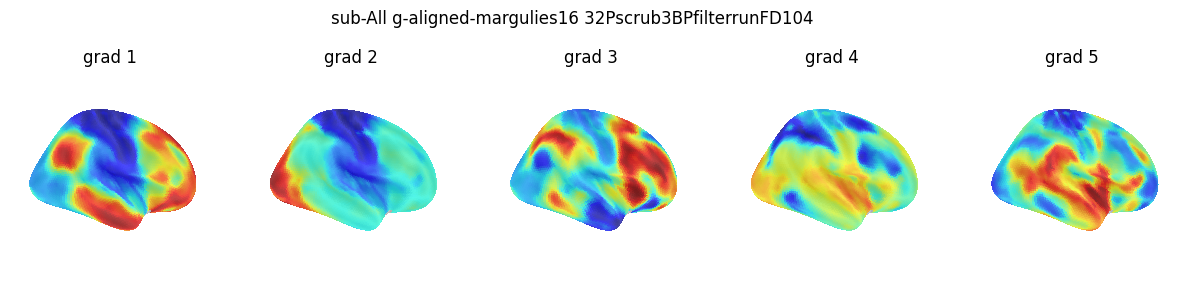

In [6]:
from utils import plot_grads

confspec =  '32Pscrub3BPfilterrunFD104' #
sub = 'All' 
add_spec = f'ses-{ses}_task-{task}_' if dataset == 'smile1' else ''

target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
spec = 'g-aligned-margulies16' # 'gradients
grad = np.load(op.join(target_dir,f'sub-{sub}_{add_spec}{spec}_space-fsaverag5_confspec-{confspec}.npy'))  
plot_grads(grad, sub, spec=spec, confspec=confspec)
plt.savefig(op.join(plot_folder,f'average_{spec}_space-fsaverag5_confspec-{confspec}.png'), dpi=300)

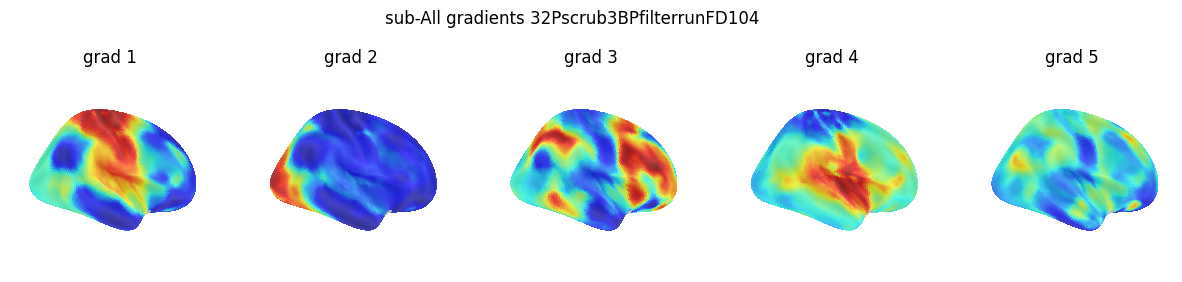

In [5]:
from utils import plot_grads

#confspec = '36Pscrub3' # 
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
spec = 'gradients'
grad = np.load(op.join(target_dir,f'sub-{sub}_{add_spec}{spec}_space-fsaverag5_confspec-{confspec}.npy'))  
plot_grads(grad, sub, spec=spec, confspec=confspec)
plt.savefig(op.join(plot_folder,f'average_{spec}_space-fsaverag5_confspec-{confspec}.png'), dpi=300)

## Gradient Coordinate Space

In [3]:
from utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
CAatlas_fsav5 = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]


In [4]:
dataset = 'dnumrisk' # 
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'

confspec='32Pscrub3BPfilterrunFD104'#'32Pscrub3'
sub = 'All'

spec = 'gradients'
add_spec = '' # ses-{ses}_task-{task}_
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')
grads = np.load(op.join(target_dir,f'sub-{sub}_{add_spec}{spec}_space-fsaverag5_confspec-{confspec}.npy'))  

df = pd.DataFrame(np.array([grads[0], grads[1], grads[2], CAatlas_fsav5]).T, columns =['g1','g2','g3','ca_network']) 

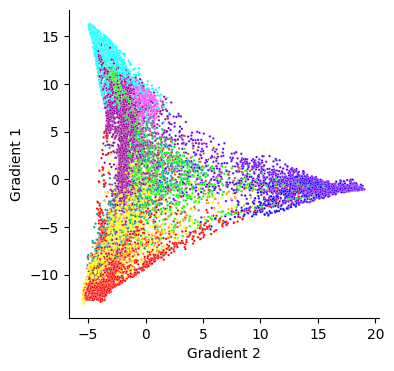

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

fig, axs = plt.subplots(1,1,figsize=(4,4))
sns.scatterplot(df, x='g2', y='g1', hue='ca_network',palette=ca_cmap,s=3, legend=False)#
#axs.set(ylim=(-15,15), xlim=(-7,20))
axs.set(xlabel='Gradient 2', ylabel='Gradient 1')
sns.despine()
plt.savefig(op.join(plot_folder, f'gradients_coordinate_space_color-network.png'), dpi=300, bbox_inches='tight')

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(-grad_all[0,:], -grad_all[1,:], -grad_all[2,:], cmap=ca_cmap, c=CAatlas_fsav5, s = 0.2)
ax.set_xlabel('grad 1')
ax.set_ylabel('grad 2')
ax.set_zlabel('grad 3')

# movable 3D plot: import plotly.graph_objects as go

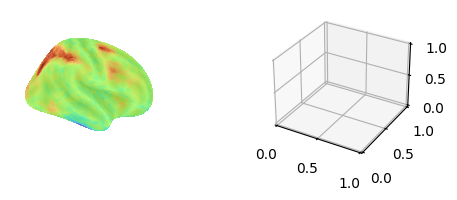

In [ ]:
# Plot nPRFs good quality
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt

group = 'all'
#fn_l = f'/mnt_03/ds-dnumrisk/derivatives/encoding_model.denoise/averages/group-{group}_desc-r2.optim.nilearn_space-fsaverage_hemi-L.func.gii'
#urf_mapL = nib.load(fn_l).agg_data()
fn_r = f'/mnt_03/ds-dnumrisk/derivatives/encoding_model.denoise/averages/group-{group}_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii'
surf_mapR = nib.load(fn_r).agg_data()

fsaverage = fetch_surf_fsaverage() # default 5
side_view = 'medial'
cmap = 'turbo' 

figure, axes = plt.subplots(nrows=1, ncols=2,figsize = (6,2), subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= surf_mapR, # infl_right # pial_right
            view= 'posterior',cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7, axes=axes[0]) #
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= surf_mapR, # infl_right # pial_right
            view= 'medial',cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7, axes=axes[0]) 


## Alignment??

In [2]:
confspec = '32Pscrub3BPfilterrunFD104' #
target_dir = op.join(bids_folder,'derivatives','gradients.tryNoHalo', f'sub-{sub}')

source_grad = np.load(op.join(target_dir,f'sub-{sub}_gradients_space-fsaverag5_confspec-{confspec}.npy'))  
target_grad = np.load(op.join(bids_folder_orig,'derivatives', 'gradients','reference_gradients_margulies16_space-fsaverage5_N-10.npy'))

In [3]:
print(source_grad.shape)
print(target_grad.shape)

(10, 20484)
(10, 20484)


In [4]:
source = source_grad[:,mask]
target = target_grad[:,mask]

In [ ]:
# orthogonal transformation: rotation + reflection
u, w, vt = np.linalg.svd(target.T.dot(source).T)
t = u.dot(vt)

aligned = source.dot(t)

In [11]:
t.shape

(18715, 18715)

In [6]:
aligned = source.dot(t)

In [ ]:
from brainspace.gradient import procrustes_alignment

aligned, reference = procrustes_alignment([source_grad[:,mask]], target_grad[:,mask], return_reference=True) # , scaling=True, reflection=True